In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from itertools import product
import copy
import sys

!rm -r /kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection
!git clone https://github.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection

rm: cannot remove '/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection': No such file or directory
Cloning into 'Architectural-Biases-in-Time-Series-Anomaly-Detection'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 147 (delta 80), reused 100 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 1.31 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (80/80), done.


### Import necessary functions/modules from git repository

In [3]:
sys.path.append("/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection")
import train
from dataset import LSTM_Dataset
from lstm import myLSTM
from utils import load_config
from evaluate import evaluate_lstm_scores

if torch.cuda.is_available():
    device = torch.device("cuda")
base_config = load_config("/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection/config.yaml")

### load device, datasets, config into environment.

In [ ]:
train_dataset = LSTM_Dataset(device, 5)
test_dataset = LSTM_Dataset(device, 5, start = 90000, end = 100000)

### General Hyperparam sweep

In [4]:
lr_list = [1e-3, 5e-4]
batch_sizes = [32, 64]
hidden_sizes = [64, 128, 256]
training_results = dict()

for lr, bs, hs in product(lr_list, batch_sizes, hidden_sizes):
    config = copy.deepcopy(base_config)
    
    config["training"]["lr"] = lr
    config["training"]["batch_size"] = bs
    config["model"]["hidden_size"] = hs
    
    config["experiment_name"] = f"lr{lr}_bs{bs}_hs{hs}"
    model = myLSTM(**config["model"]).to(device)
    training_results[config["experiment_name"]] = \
    train.fit_lstm(model, config["experiment_name"], train_dataset, test_dataset, **config["training"])
    print()
    

| experiment: lr0.001_bs32_hs64 | epoch 10, train: MSE 0.0204, test MSE: 0.0329
update LR: 0.001 -> 0.0005
| experiment: lr0.001_bs32_hs64 | epoch 20, train: MSE 0.0126, test MSE: 0.0163
update LR: 0.0005 -> 0.00025
| experiment: lr0.001_bs32_hs64 | epoch 30, train: MSE 0.0112, test MSE: 0.0141
update LR: 0.00025 -> 0.000125
| experiment: lr0.001_bs32_hs64 | epoch 40, train: MSE 0.0108, test MSE: 0.0133
update LR: 0.000125 -> 6.25e-05
| experiment: lr0.001_bs32_hs64 | epoch 50, train: MSE 0.0107, test MSE: 0.0130
update LR: 6.25e-05 -> 3.125e-05
update LR: 3.125e-05 -> 1.5625e-05
| experiment: lr0.001_bs32_hs64 | epoch 60, train: MSE 0.0106, test MSE: 0.0126
update LR: 1.5625e-05 -> 7.8125e-06
update LR: 7.8125e-06 -> 3.90625e-06
| experiment: lr0.001_bs32_hs64 | epoch 65, train: MSE 0.0106, test MSE: 0.0126
Stopping early

| experiment: lr0.001_bs32_hs128 | epoch 10, train: MSE 0.0205, test MSE: 0.0389
update LR: 0.001 -> 0.0005
| experiment: lr0.001_bs32_hs128 | epoch 20, train: MSE 

### Comparing test losses for exeriments that ran for the maximum number of epochs (70)

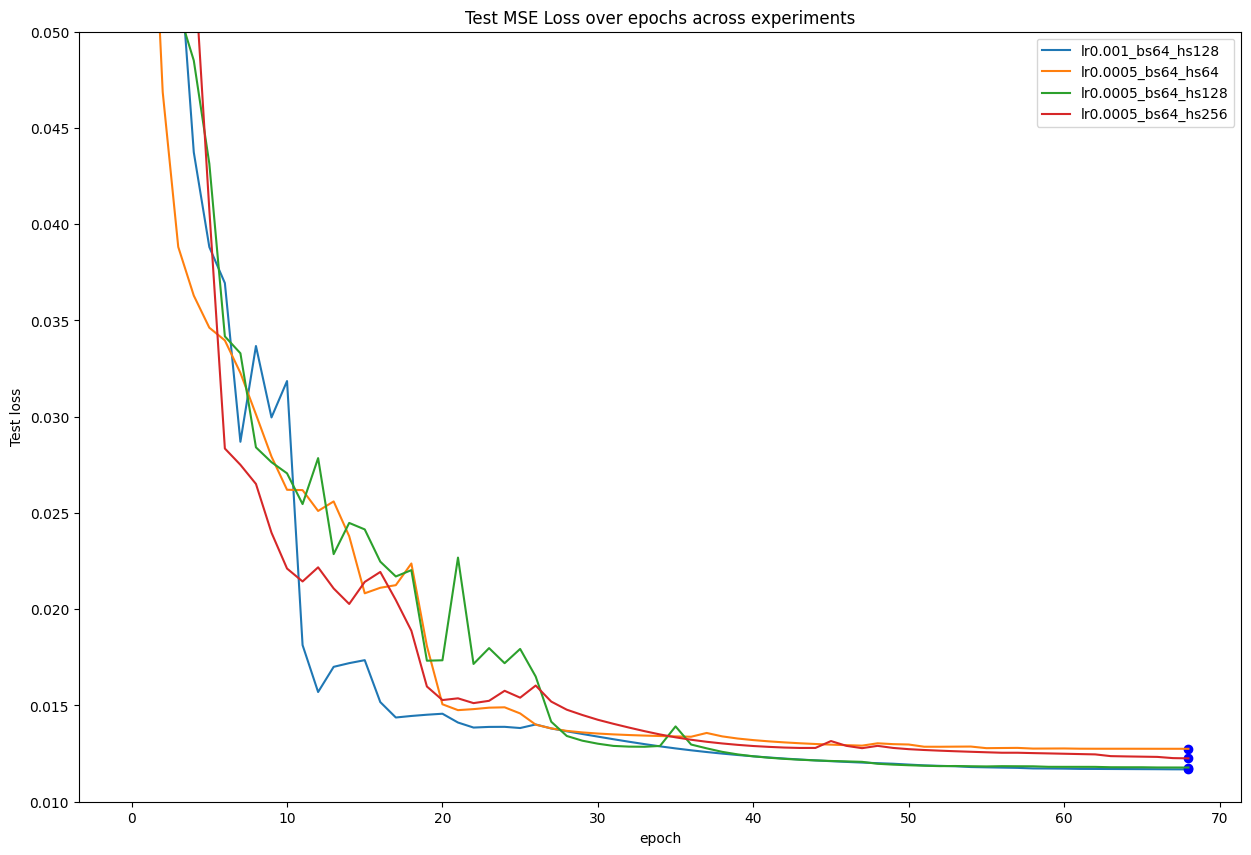

In [74]:
plt.figure(figsize=(15, 10))
colors = plt.cm.tab20(np.linspace(0, 1, len(training_results)))
for ex_name, result in training_results.items():
    test_array = result[2]
    if len(test_array) == 69:
        plt.plot(np.argmin(test_array), np.min(test_array), 'o', c = "blue")
        plt.plot(range(config["training"]["num_epochs"] - 1), 
                 test_array,
                label = ex_name)
plt.ylim(0.01, 0.05)
plt.xlabel("epoch")
plt.ylabel("Test loss")
plt.title("Test MSE Loss over epochs across experiments")
plt.legend()
plt.show()

### Based on the graph, hs = 128 seems to be the sweet spot. Batch sizes could be made bigger (since bs64 dominates bs32). Learning rate should be tested more.

In [73]:
# Not increasing LR for larger batches, because experiments show that model plateaus quite early on, and LR needs to be lower
lr_list = [5e-4, 2.5e-4] 
batch_sizes = [128, 256]
hidden_sizes = [128]
training_results_2 = dict()

for lr, bs, hs in product(lr_list, batch_sizes, hidden_sizes):
    config2 = copy.deepcopy(base_config)
    
    config2["training"]["lr"] = lr
    config2["training"]["batch_size"] = bs
    config2["model"]["hidden_size"] = hs
    config2["training"]["num_epochs"] = 100
    config2["experiment_name"] = f"lr{lr}_bs{bs}_hs{hs}"
    model = myLSTM(**config2["model"]).to(device)
    training_results_2[config2["experiment_name"]] = \
    train.fit_lstm(model, config2["experiment_name"], train_dataset, test_dataset, **config2["training"])
    print()
    

| experiment: lr0.0005_bs128_hs128 | epoch 10, train: MSE 0.0171, test MSE: 0.0260
update LR: 0.0005 -> 0.00025
| experiment: lr0.0005_bs128_hs128 | epoch 20, train: MSE 0.0126, test MSE: 0.0171
| experiment: lr0.0005_bs128_hs128 | epoch 30, train: MSE 0.0122, test MSE: 0.0165
update LR: 0.00025 -> 0.000125
update LR: 0.000125 -> 6.25e-05
update LR: 6.25e-05 -> 3.125e-05
| experiment: lr0.0005_bs128_hs128 | epoch 40, train: MSE 0.0109, test MSE: 0.0141
| experiment: lr0.0005_bs128_hs128 | epoch 50, train: MSE 0.0107, test MSE: 0.0133
update LR: 3.125e-05 -> 1.5625e-05
| experiment: lr0.0005_bs128_hs128 | epoch 60, train: MSE 0.0107, test MSE: 0.0130
update LR: 1.5625e-05 -> 7.8125e-06
update LR: 7.8125e-06 -> 3.90625e-06
update LR: 3.90625e-06 -> 1.953125e-06
| experiment: lr0.0005_bs128_hs128 | epoch 67, train: MSE 0.0106, test MSE: 0.0130
Stopping early

| experiment: lr0.0005_bs256_hs128 | epoch 10, train: MSE 0.0186, test MSE: 0.0361
update LR: 0.0005 -> 0.00025
| experiment: lr0.0

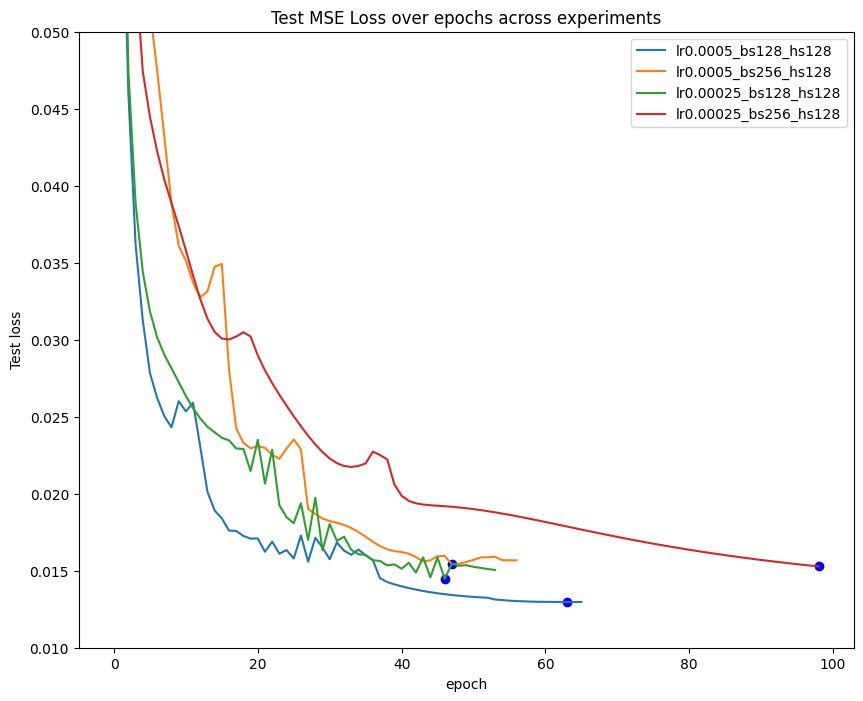

In [77]:
plt.figure(figsize=(10, 8))
for ex_name, result in training_results_2.items():
    test_array = result[2]
    plt.plot(np.argmin(test_array), np.min(test_array), 'o', c = "blue")
    plt.plot(range(config2["training"]["num_epochs"]), 
             np.pad(test_array, pad_width=(0, 100 - len(test_array)), mode='constant', constant_values=np.nan),
            label = ex_name)
plt.ylim(0.01, 0.05)
plt.xlabel("epoch")
plt.ylabel("Test loss")
plt.title("Test MSE Loss over epochs across experiments")
plt.legend()
plt.show()

### No significant improvement for larger batch sizes for this config. Sticking to 64 batches, hidden_size of 128, and initial lr of 0.001. <br> Since I'm not going for best accuracy/performance, this is good enough.

### Training on 80% of the nominal dataset (800 000 samples), validating on 200 000 samples.

In [4]:
full_training_dataset = LSTM_Dataset(device, 5, start = 0, end = 1000000 - 200000)
full_testing_dataset = LSTM_Dataset(device, 5, start = 1000000 - 200000, end = 1000000)

In [5]:
final_results = dict()
final_config = copy.deepcopy(base_config)

final_config["training"]["lr"] = 0.001
final_config["training"]["batch_size"] = 64
final_config["training"]["num_epochs"] = 100
final_config["model"]["hidden_size"] = 128

final_config["experiment_name"] = f"lr{0.001}_bs{64}_hs{128}"
final_short_window_lstm = myLSTM(**final_config["model"]).to(device)

In [6]:
final_results[final_config["experiment_name"]] = \
train.fit_lstm(final_short_window_lstm, final_config["experiment_name"], 
               full_training_dataset, full_testing_dataset, **final_config["training"])
print()

| experiment: lr0.001_bs64_hs128 | epoch 10, train: MSE 0.0208, test MSE: 0.0293
| experiment: lr0.001_bs64_hs128 | epoch 20, train: MSE 0.0190, test MSE: 0.0254
update LR: 0.001 -> 0.0005
| experiment: lr0.001_bs64_hs128 | epoch 30, train: MSE 0.0125, test MSE: 0.0146
update LR: 0.0005 -> 0.00025
| experiment: lr0.001_bs64_hs128 | epoch 40, train: MSE 0.0111, test MSE: 0.0120
update LR: 0.00025 -> 0.000125
update LR: 0.000125 -> 6.25e-05
| experiment: lr0.001_bs64_hs128 | epoch 50, train: MSE 0.0106, test MSE: 0.0111
update LR: 6.25e-05 -> 3.125e-05
update LR: 3.125e-05 -> 1.5625e-05
| experiment: lr0.001_bs64_hs128 | epoch 60, train: MSE 0.0105, test MSE: 0.0109
update LR: 1.5625e-05 -> 7.8125e-06
update LR: 7.8125e-06 -> 3.90625e-06
update LR: 3.90625e-06 -> 1.953125e-06
| experiment: lr0.001_bs64_hs128 | epoch 70, train: MSE 0.0104, test MSE: 0.0108
update LR: 1.953125e-06 -> 9.765625e-07
| experiment: lr0.001_bs64_hs128 | epoch 73, train: MSE 0.0104, test MSE: 0.0108
Stopping earl

In [7]:
torch.save(final_short_window_lstm.state_dict(), "LSTM_short_window_weights.pth")

### Tuning the treshold on a separate validation data that contains anomalies

#### First determine a grid of initial threshold values from the clean testing dataset

In [21]:
bp = int(len(full_testing_dataset)/2)
with torch.no_grad():
    y_true_1 = full_testing_dataset.y[:bp].cpu().numpy()
    y_pred_1 = final_short_window_lstm(full_testing_dataset.X[:bp]).cpu().numpy()

    y_true_2 = full_testing_dataset.y[bp:].cpu().numpy()
    y_pred_2 = final_short_window_lstm(full_testing_dataset.X[bp:]).cpu().numpy()

errors = np.concatenate([
    y_pred_1 - y_true_1,
    y_pred_2 - y_true_2
])

In [164]:
train_scores = np.linalg.norm(errors, axis=1)
treshold = np.max(sorted_scores[int(len(sorted_scores) * 0.97)]).item()
treshold

0.9206531047821045

#### New contaminated dataset used to sweep over the thresholds

In [23]:
forecasting_validation_dataset = LSTM_Dataset(device, 5, start = 1000000, end = 3500000, train = False)
forecasting_testing_dataset = LSTM_Dataset(device, 5, start = 3500000, end = 5000000, train = False)

### evaluate once on the start = 1000000, end = 350000 validation dataset

In [39]:
scores, labels = evaluate_lstm_scores(final_short_window_lstm, forecasting_validation_dataset)

### Sweep over all tresholds and some windows.

In [166]:
from sklearn.metrics import roc_auc_score
window_grid = [1, 25, 300, 400, 500, 600]

for window in window_grid:
    current_score = scores
    if window > 1:
        current_score = np.convolve(scores, np.ones(window) / window, mode='same')
    auc_score = roc_auc_score(labels, current_score > threshold)   
    print(f'window: {window}| auc: {auc_score:.4f}')


window: 1| auc: 0.5648
window: 25| auc: 0.5903
window: 300| auc: 0.6036
window: 400| auc: 0.6059
window: 500| auc: 0.6079
window: 600| auc: 0.6061


### This param configuration is the most promising

#### | evaluation_threshold: 0.92 | window: 500 |

In [167]:
threshold, window = 0.92, 500
current_test_score = np.convolve(scores, np.ones(window) / window, mode='same')
TP = np.sum((current_test_score > threshold) & (labels == 1))
FP = np.sum((current_test_score > threshold) & (labels == 0))
recall = TP/forecasting_validation_dataset.total_anomalies
precision = TP/(TP + FP)
F1 = 2 * (precision * recall)/(precision + recall)
print(f"| evaluation_threshold: {threshold} | window: {window} | recall {recall}, precision {precision}, F1 {F1}")

| evaluation_threshold: 0.92 | window: 500 | recall 0.19493248610007943, precision 0.9075847786694279, F1 0.3209342164625575


### Brief interpretation of the scoring and anomaly smoothing.

In [83]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/kirillvishnyakov/cats-dataset/data.csv")
df_validate = df[1000000: 3500000]
df_test = df[3500000:]

In [168]:
def visualize_scores(start, end, window = 1, title = ""):

    scores_plot = np.array(scores)[start: end]
    labels_plot = np.array(labels)[start: end]
    
    # plot
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    
    ax1.plot(scores_plot, linewidth=0.5)
    ax1.axhline(y=0.92, color='r', linestyle='--', label='threshold=0.92')
    ax1.set_ylabel('anomaly score')
    ax1.legend()

    ax2.plot(np.convolve(scores_plot, np.ones(window) / window, mode='same'), linewidth=0.5)
    ax2.axhline(y=0.92, color='b', linestyle='--', label='threshold=0.92')
    ax2.set_ylabel('anomaly smoothed score')
    ax2.legend()
    
    ax3.plot(labels_plot, linewidth=0.5, color='orange')
    ax3.set_ylabel('anomaly label')
    ax3.set_xlabel('timestep')
    ticks = ax3.get_xticks()
    ax3.set_xticklabels([int(tick + start) for tick in ticks])
    plt.title(title)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/2458370958.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([int(tick + start) for tick in ticks])


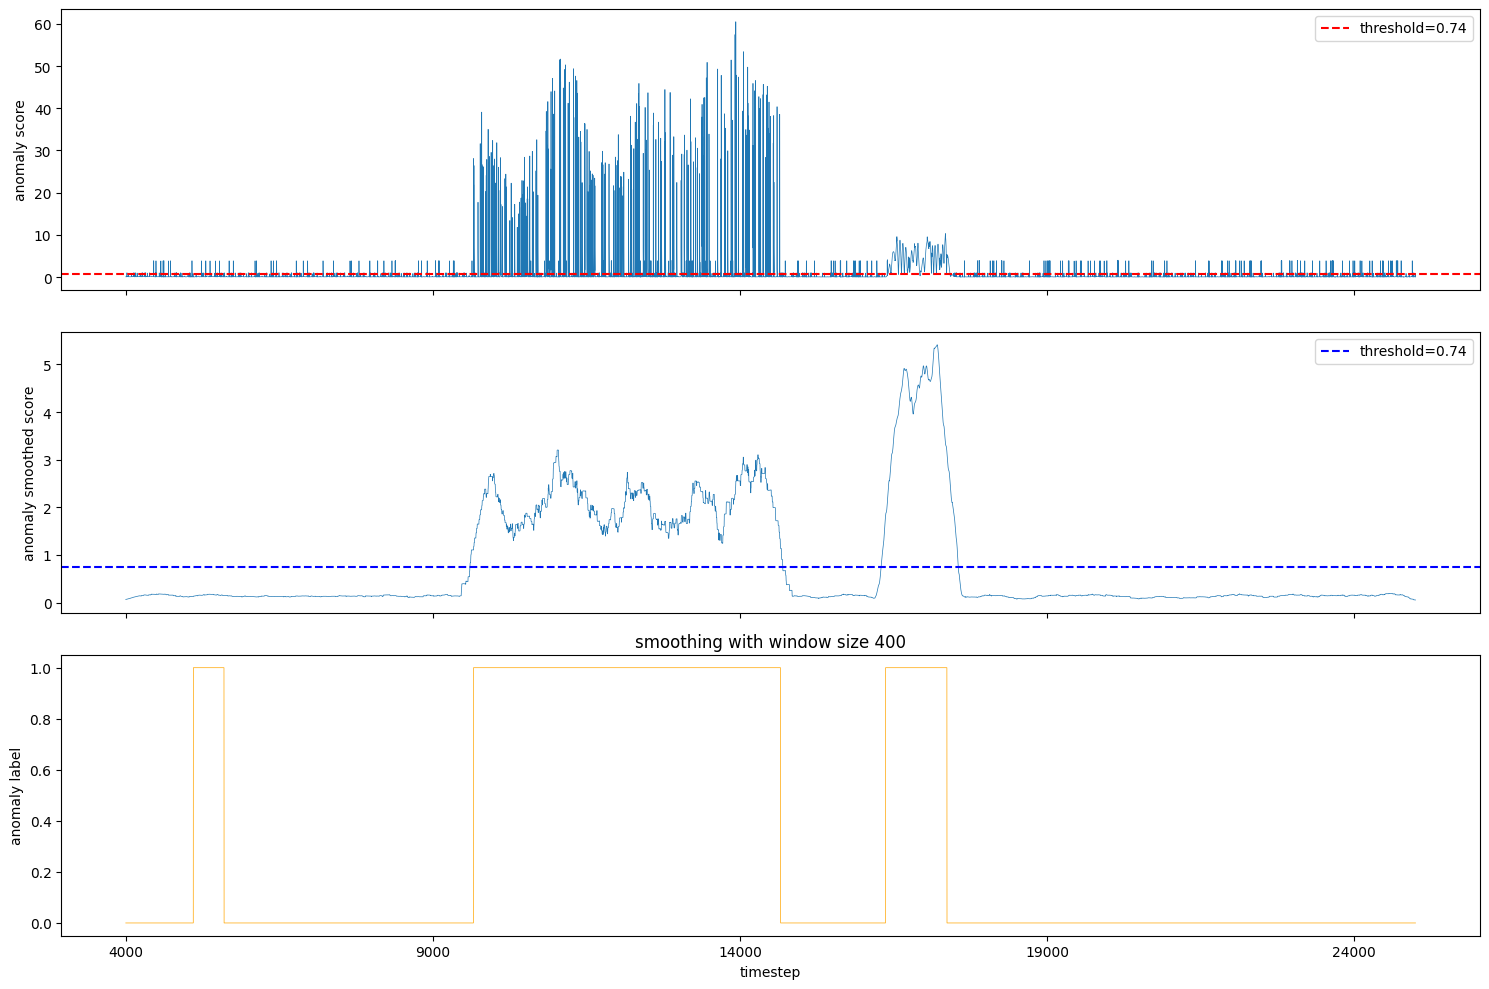

In [159]:
visualize_scores(4000, 25000, 400, title = "smoothing with window size 400")

In [84]:
print(df_validate[4000:8000]["category"].value_counts())
print(df_validate[9000:15000]["category"].value_counts())
print(df_validate[15000:19000]["category"].value_counts())

category
0.0     3500
12.0     500
Name: count, dtype: int64
category
1.0    5000
0.0    1000
Name: count, dtype: int64
category
0.0    3000
8.0    1000
Name: count, dtype: int64


#### From the graph and the print statements, the model is bad at predicting anomalies of type 12. <br> It detects types 1 and 8. <br> Additionally, there are false positive basically everywhere.

#### Overall, anomaly smoothing seems to help a lot with false positives (improves precision -> F1 score) and Recall also goes up. <br><br> However, recall improving as window size increases might be due to the model prioritizing one type of anomaly and disregarding another one completely. In other word, I might be overfitting the best window size/threshold for this portion of this dataset.

### Before evaluating the best model + threshold and window size. <br> Need to compare anomaly class imbalances between the validation and testing datasets.

In [115]:
comparison = pd.DataFrame({
    "validate": df_validate["category"].value_counts().sort_index(),
    "test": df_test["category"].value_counts().sort_index()
}) * 100

print(comparison)

           validate       test
category                      
0.0       237410000  143580000
1.0         1260000     780000
2.0          900000     300000
3.0          340000    1460000
4.0          990000     570000
5.0          490000     500000
6.0         1100000     110000
7.0         1580000     330000
8.0         2310000     950000
9.0          430000     610000
10.0         500000     140000
11.0         870000      40000
12.0        1520000     440000
13.0         300000     190000


#### Some of these imbalances do look dramatic, for example:
#### class 3: 340000 -> 1460000 <br>class 6: 1100000 -> 110000 <br>class 11: 870000 -> 40000
#### It's not catastrophic because those classes are still well represented in both datasets.

### Now evaluating metrics on the testing dataset

In [117]:
test_scores, test_labels = evaluate_lstm_scores(final_short_window_lstm, forecasting_testing_dataset)

In [170]:
threshold, window = 0.92, 500
current_test_score = np.convolve(test_scores, np.ones(window) / window, mode='same')
TP = np.sum((current_test_score > threshold) & (test_labels == 1))
FP = np.sum((current_test_score > threshold) & (test_labels == 0))
recall = TP/forecasting_testing_dataset.total_anomalies
precision = TP/(TP + FP)
F1 = 2 * (precision * recall)/(precision + recall)
print(f"| evaluation_threshold: {threshold} | window: {window} | recall {recall}, precision {precision}, F1 {F1}")

| evaluation_threshold: 0.92 | window: 500 | recall 0.2930373831775701, precision 0.8712949240459429, F1 0.43857236105930625


### Comparing with statistical baseline

In [172]:
import numpy as np
from sklearn.metrics import f1_score
import torch

series = np.array([torch.linalg.norm(forecasting_testing_dataset[idx][1]).item() for idx in range(len(forecasting_testing_dataset))])
y_true = np.array([forecasting_testing_dataset[idx][2] for idx in range(len(forecasting_testing_dataset))])

threshold = series.mean() + 3 * series.std()
baseline_preds = (series > threshold).astype(int)

f1_baseline = f1_score(y_true, baseline_preds)
print("Simple global mean+3*std baseline F1:", f1_baseline)

Simple global mean+3*std baseline F1: 0.2891641386587369


## TODO: Pick small and large smoothing windows and anomaly class breakdowns at the end instead of single F1 score (need to add category as outp in Dataset)

### 